#Importing Libraries

In [9]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import when, col
from pyspark.ml.feature import VectorAssembler, StandardScaler
from pyspark.ml.classification import LogisticRegression
from pyspark.ml.classification import DecisionTreeClassifier
from pyspark.ml.classification import LinearSVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_curve, auc
from sklearn.metrics import precision_recall_curve
from pyspark.sql.functions import rand
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
from pyspark.sql.functions import udf
from pyspark.ml.linalg import Vectors, VectorUDT
import shap
from pyspark.sql.functions import count, when, isnan, col
from matplotlib.colors import LogNorm

#Creation of the Spark Session

In [2]:
spark = SparkSession.builder \
    .appName("Task5_Model_Comparison") \
    .master("local[*]") \
    .getOrCreate()


print("SPARK SESSION CREATED")



print("Spark Version:", spark.version)

SPARK SESSION CREATED
Spark Version: 4.0.2


#Loading the Dataset

In [3]:
df = spark.read.csv(
    "/content/DelayData.csv",
    header=True,
    inferSchema=True
)


#Preview of the Dataset

In [4]:
df.show(6)


+--------+--------+-----------------------+------+----+-------------+-----------------+---------------+----------+----------+-------------------+---------------------+----------------------+---------------------+-----------------+-------------------+--------------------+-------------------+-------------------+---------------------+----------------------+---------------------+-----------------+-------------------+--------------------+-------------------+----+-----+----------+---------+-------------+---------------+-------------+-------+--------+----------+----------+--------------------+-----------+--------+-------------+-----------------+---------------+----------+---------+----------+----------+----------+-------------+----------------+----------------+-------------+-------------+---------+--------------+---------+--------------+--------------+-----------------------+------------+---------------------+
|depdelay|arrdelay|scheduleddepartdatetime|origin|dest|uniquecarrier|marketshareori

#Target Variable

In [5]:
df = df.withColumn(
    "delay_label",
    when(col("arrdelay") > 15, 1).otherwise(0)
)


#Feature Selection

In [6]:
feature_columns = [
    "distance",
    "temperature",
    "windspeed",
    "capacity",
    "loadfactor",
    "scheduledhour"
]

***Checking NAN Values***

In [10]:


df.select([
    count(
        when(
            isnan(col(c)) | col(c).isNull(),
            c
        )
    ).alias(c)
    for c in feature_columns
]).show()

+--------+-----------+---------+--------+----------+-------------+
|distance|temperature|windspeed|capacity|loadfactor|scheduledhour|
+--------+-----------+---------+--------+----------+-------------+
|       0|        460|      460|       0|         0|            0|
+--------+-----------+---------+--------+----------+-------------+



#Vector Assembler

In [11]:
assembler = VectorAssembler(
    inputCols=feature_columns,
    outputCol="assembled_features"
)

assembled_df = assembler.transform(df)

#Standard Scaler

In [13]:
feature_columns = [
    "distance",
    "temperature",
    "windspeed",
    "capacity",
    "loadfactor",
    "scheduledhour"
]

clean_df = df.na.drop(
    subset=feature_columns
)

assembled_df = assembler.transform(
    clean_df
)

In [14]:
scaler = StandardScaler(
    inputCol="assembled_features",
    outputCol="features",
    withMean=True,
    withStd=True
)

scaler_model = scaler.fit(
    assembled_df
)

processed_df = scaler_model.transform(
    assembled_df
)

In [16]:
processed_df.select(
    "delay_label",
    "features"
).show(5, truncate=False)

+-----------+-------------------------------------------------------------------------------------------------------------------------+
|delay_label|features                                                                                                                 |
+-----------+-------------------------------------------------------------------------------------------------------------------------+
|0          |[-0.49178002047054886,-0.1810780521273772,0.28400994828846826,-2.1264525105678422,-2.956397544907396,0.4154299625212682] |
|0          |[-0.6172988610150024,-0.5482856527933839,0.9188727104609608,-2.1264525105678422,-1.5365280309308273,0.20293781566184266] |
|0          |[1.0904645187869997,-0.4795424846262513,0.8927808353109639,0.23534291457850928,-2.998626179400761,-0.22204647805700845]  |
|1          |[2.8760142223066913,-0.7873531011436486,-1.65829295776399,0.3534326858358269,-2.291071538483017,0.4154299625212682]      |
|0          |[-0.622602473995754,-2.744518611637

#Train-Test Split

In [17]:
train_df, test_df = processed_df.randomSplit(
    [0.8, 0.2],
    seed=42
)

print("Training Rows:", train_df.count())
print("Testing Rows:", test_df.count())

Training Rows: 960937
Testing Rows: 240267


In [18]:
processed_df.select(
    "delay_label",
    "features"
).show(5, truncate=False)

+-----------+-------------------------------------------------------------------------------------------------------------------------+
|delay_label|features                                                                                                                 |
+-----------+-------------------------------------------------------------------------------------------------------------------------+
|0          |[-0.49178002047054886,-0.1810780521273772,0.28400994828846826,-2.1264525105678422,-2.956397544907396,0.4154299625212682] |
|0          |[-0.6172988610150024,-0.5482856527933839,0.9188727104609608,-2.1264525105678422,-1.5365280309308273,0.20293781566184266] |
|0          |[1.0904645187869997,-0.4795424846262513,0.8927808353109639,0.23534291457850928,-2.998626179400761,-0.22204647805700845]  |
|1          |[2.8760142223066913,-0.7873531011436486,-1.65829295776399,0.3534326858358269,-2.291071538483017,0.4154299625212682]      |
|0          |[-0.622602473995754,-2.744518611637

#Logistic Regression Model

In [19]:


lr = LogisticRegression(
    featuresCol="features",
    labelCol="delay_label"
)

lr_model = lr.fit(train_df)

lr_predictions = lr_model.transform(test_df)

lr_predictions.select(
    "delay_label",
    "prediction"
).show(5)

+-----------+----------+
|delay_label|prediction|
+-----------+----------+
|          0|       0.0|
|          0|       0.0|
|          0|       0.0|
|          0|       0.0|
|          1|       0.0|
+-----------+----------+
only showing top 5 rows


#Decision Tree

In [20]:
dt = DecisionTreeClassifier(
    featuresCol="features",
    labelCol="delay_label"
)

dt_model = dt.fit(train_df)

dt_predictions = dt_model.transform(test_df)

dt_predictions.select(
    "delay_label",
    "prediction"
).show(5)

+-----------+----------+
|delay_label|prediction|
+-----------+----------+
|          0|       0.0|
|          0|       0.0|
|          0|       0.0|
|          0|       0.0|
|          1|       0.0|
+-----------+----------+
only showing top 5 rows


#SVM

In [21]:
svm = LinearSVC(
    featuresCol="features",
    labelCol="delay_label"
)

svm_model = svm.fit(train_df)

svm_predictions = svm_model.transform(test_df)

svm_predictions.select(
    "delay_label",
    "prediction"
).show(5)

+-----------+----------+
|delay_label|prediction|
+-----------+----------+
|          0|       0.0|
|          0|       0.0|
|          0|       0.0|
|          0|       0.0|
|          1|       0.0|
+-----------+----------+
only showing top 5 rows


#KNN

In [22]:


# Conversion of Spark DataFrame to Pandas

train_pd = train_df.select(
    "features",
    "delay_label"
).toPandas()

test_pd = test_df.select(
    "features",
    "delay_label"
).toPandas()

# Creation of X and y

X_train = train_pd["features"].apply(
    lambda x: x.toArray()
).tolist()

y_train = train_pd["delay_label"]

X_test = test_pd["features"].apply(
    lambda x: x.toArray()
).tolist()

y_test = test_pd["delay_label"]

# Training KNN

knn = KNeighborsClassifier(
    n_neighbors=5
)

knn.fit(
    X_train,
    y_train

)

# Predictions

y_pred = knn.predict(X_test)



#Logistic Regression Confusion Matrix

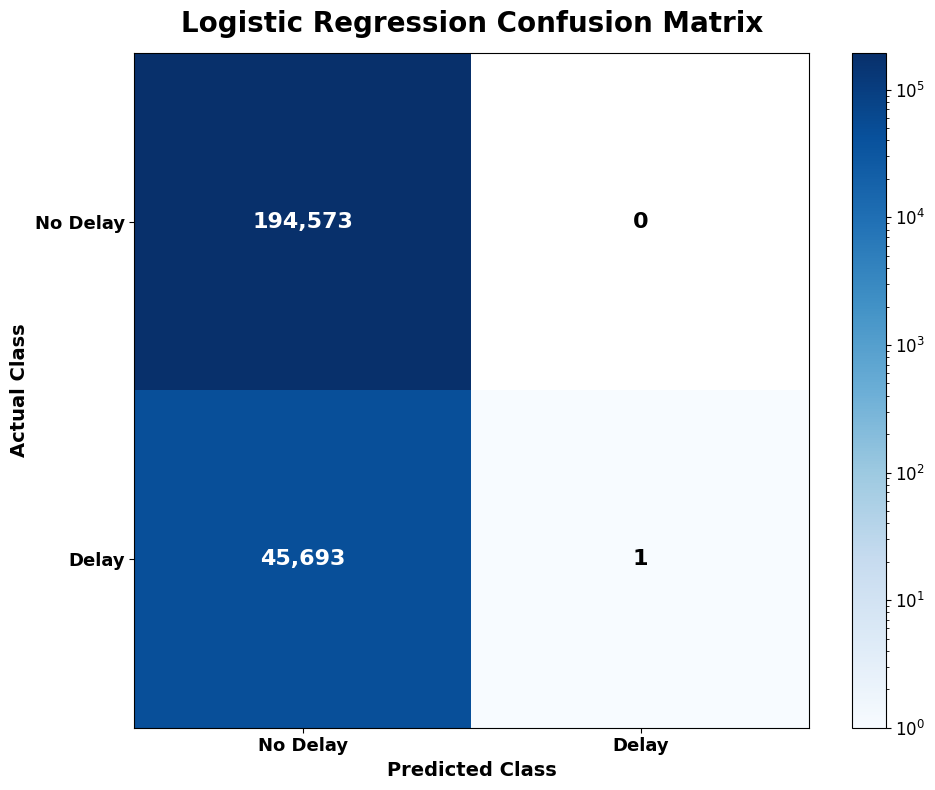

In [27]:
from matplotlib.colors import LogNorm
y_true_lr = [
    row["delay_label"]
    for row in lr_predictions.select("delay_label").collect()
]

y_pred_lr = [
    int(row["prediction"])
    for row in lr_predictions.select("prediction").collect()
]

# Creation of confusion matrix

cm_lr = confusion_matrix(
    y_true_lr,
    y_pred_lr
)

# Plot

fig, ax = plt.subplots(figsize=(10, 8))

im = ax.imshow(
    cm_lr,
    cmap="Blues",
    norm=LogNorm(vmin=1, vmax=max(cm_lr.max(), 1))
)

classes = ["No Delay", "Delay"]

ax.set_xticks(np.arange(len(classes)))
ax.set_yticks(np.arange(len(classes)))

ax.set_xticklabels(classes, fontsize=13, fontweight="bold")
ax.set_yticklabels(classes, fontsize=13, fontweight="bold")

ax.set_xlabel(
    "Predicted Class",
    fontsize=14,
    fontweight="bold"
)

ax.set_ylabel(
    "Actual Class",
    fontsize=14,
    fontweight="bold"
)

ax.set_title(
    "Logistic Regression Confusion Matrix",
    fontsize=20,
    fontweight="bold",
    pad=15
)

for i in range(cm_lr.shape[0]):
    for j in range(cm_lr.shape[1]):

        value = cm_lr[i, j]

        ax.text(
            j,
            i,
            f"{value:,}",
            ha="center",
            va="center",
            fontsize=16,
            fontweight="bold",
            color="white" if value > cm_lr.max()/5 else "black"
        )

cbar = plt.colorbar(im)
cbar.ax.tick_params(labelsize=12)

plt.tight_layout()
plt.show()


#Decision Tree Confusion Matrix

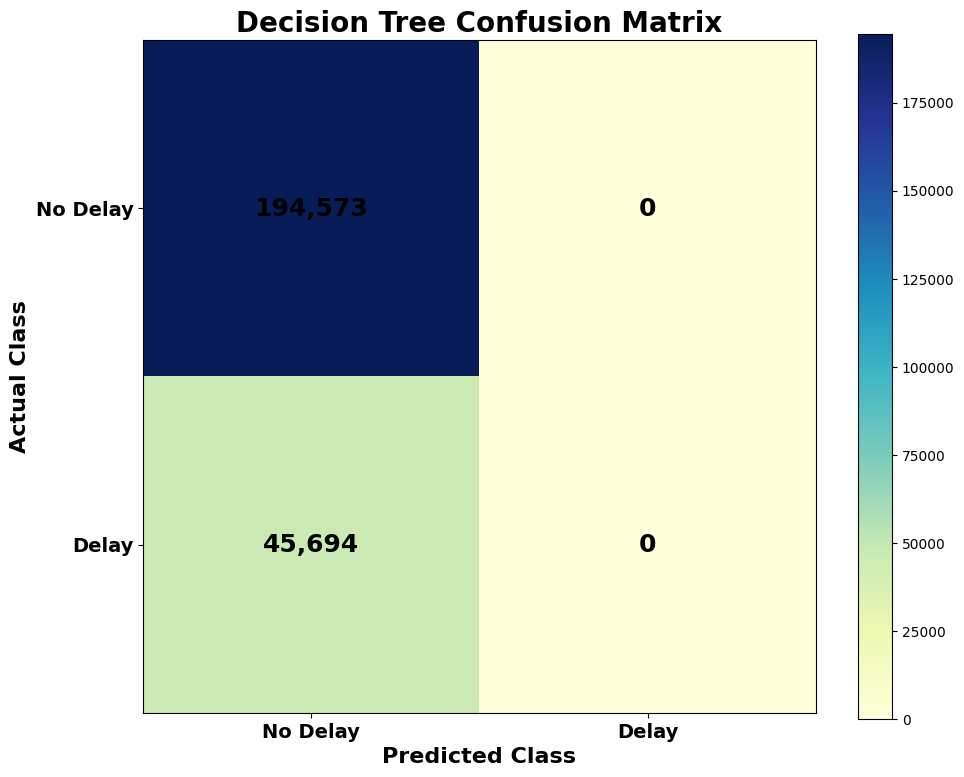

In [28]:


y_true = [
    row["delay_label"]
    for row in dt_predictions.select("delay_label").collect()
]

y_pred = [
    row["prediction"]
    for row in dt_predictions.select("prediction").collect()
]

cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(10,8))

im = ax.imshow(cm, cmap="YlGnBu")

classes = ["No Delay", "Delay"]

ax.set_xticks(np.arange(len(classes)))
ax.set_yticks(np.arange(len(classes)))

ax.set_xticklabels(classes, fontsize=14, fontweight='bold')
ax.set_yticklabels(classes, fontsize=14, fontweight='bold')

ax.set_xlabel("Predicted Class", fontsize=16, fontweight='bold')
ax.set_ylabel("Actual Class", fontsize=16, fontweight='bold')

ax.set_title(
    "Decision Tree Confusion Matrix",
    fontsize=20,
    fontweight='bold'
)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(
            j,
            i,
            f"{cm[i,j]:,}",
            ha="center",
            va="center",
            fontsize=18,
            fontweight="bold",
            color="black"
        )

plt.colorbar(im)
plt.tight_layout()
plt.show()

#SVM Confusion Matrix

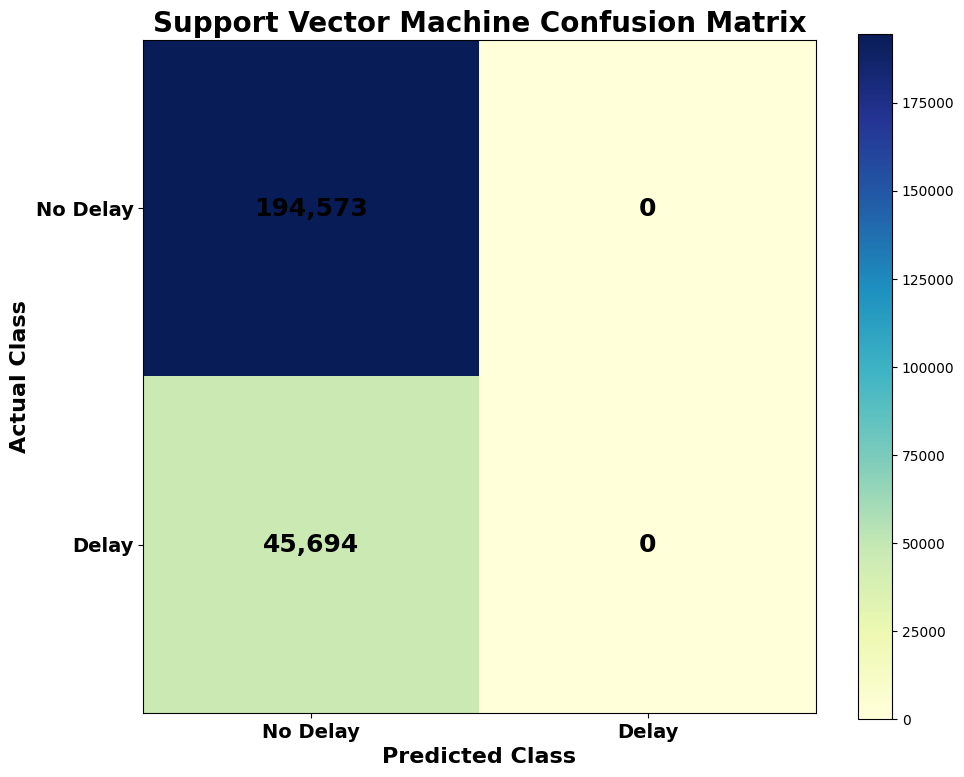

In [29]:


cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(10,8))

im = ax.imshow(cm, cmap="YlGnBu")

classes = ["No Delay", "Delay"]

ax.set_xticks(np.arange(2))
ax.set_yticks(np.arange(2))

ax.set_xticklabels(classes, fontsize=14, fontweight="bold")
ax.set_yticklabels(classes, fontsize=14, fontweight="bold")

ax.set_xlabel(
    "Predicted Class",
    fontsize=16,
    fontweight="bold"
)

ax.set_ylabel(
    "Actual Class",
    fontsize=16,
    fontweight="bold"
)

ax.set_title(
    "Support Vector Machine Confusion Matrix",
    fontsize=20,
    fontweight="bold"
)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(
            j,
            i,
            f"{cm[i,j]:,}",
            ha="center",
            va="center",
            fontsize=18,
            fontweight="bold",
            color="black"
        )

plt.colorbar(im)
plt.tight_layout()
plt.show()

#KNN Confusion Matrix

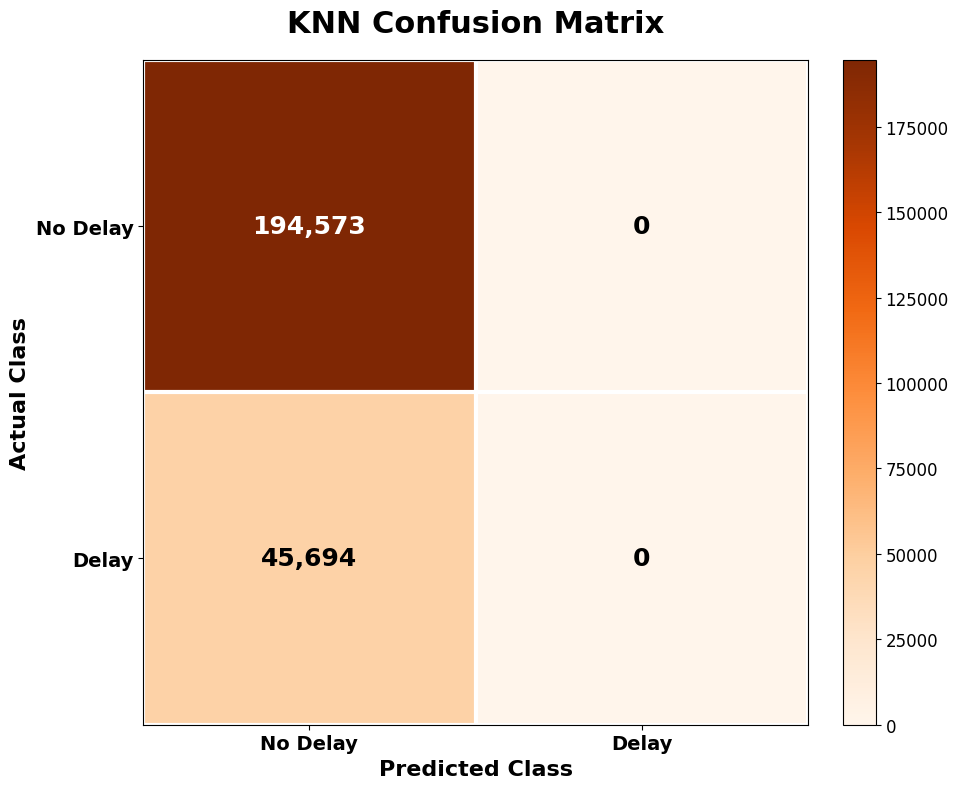

In [30]:
cm_knn = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(10, 8))

im = ax.imshow(
    cm_knn,
    cmap="Oranges",
    interpolation="nearest"
)

classes = ["No Delay", "Delay"]

ax.set_xticks(np.arange(len(classes)))
ax.set_yticks(np.arange(len(classes)))

ax.set_xticklabels(
    classes,
    fontsize=14,
    fontweight="bold"
)

ax.set_yticklabels(
    classes,
    fontsize=14,
    fontweight="bold"
)

ax.set_xlabel(
    "Predicted Class",
    fontsize=16,
    fontweight="bold"
)

ax.set_ylabel(
    "Actual Class",
    fontsize=16,
    fontweight="bold"
)

ax.set_title(
    "KNN Confusion Matrix",
    fontsize=22,
    fontweight="bold",
    pad=20
)

# White grid lines

ax.set_xticks(np.arange(-0.5, 2, 1), minor=True)
ax.set_yticks(np.arange(-0.5, 2, 1), minor=True)

ax.grid(
    which="minor",
    color="white",
    linestyle="-",
    linewidth=3
)

ax.tick_params(which="minor", bottom=False, left=False)

# Dynamic text colour

threshold = cm_knn.max() * 0.4

for i in range(cm_knn.shape[0]):
    for j in range(cm_knn.shape[1]):

        ax.text(
            j,
            i,
            f"{cm_knn[i, j]:,}",
            ha="center",
            va="center",
            fontsize=18,
            fontweight="bold",
            color="white" if cm_knn[i, j] > threshold else "black"
        )

# Premium colorbar

cbar = plt.colorbar(
    im,
    fraction=0.046,
    pad=0.04
)

cbar.ax.tick_params(
    labelsize=12
)

plt.tight_layout()

plt.show()

#Logistic Rergression- ROC Curve

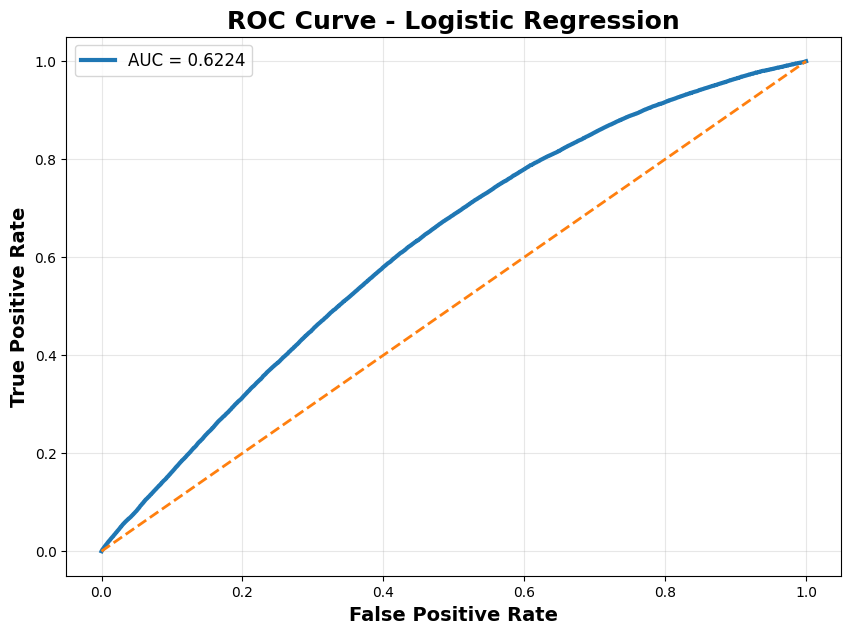

AUC Score: 0.6224


In [31]:
# Actual values

y_true = [
    row["delay_label"]
    for row in lr_predictions.select("delay_label").collect()
]

# Probability of Class 1 (Delay)

y_score = [
    float(row["probability"][1])
    for row in lr_predictions.select("probability").collect()
]

# ROC Calculation

fpr, tpr, thresholds = roc_curve(
    y_true,
    y_score
)

roc_auc = auc(
    fpr,
    tpr
)

# Plot

plt.figure(figsize=(10,7))

plt.plot(
    fpr,
    tpr,
    linewidth=3,
    label=f"AUC = {roc_auc:.4f}"
)

plt.plot(
    [0,1],
    [0,1],
    linestyle="--",
    linewidth=2
)

plt.xlabel(
    "False Positive Rate",
    fontsize=14,
    fontweight="bold"
)

plt.ylabel(
    "True Positive Rate",
    fontsize=14,
    fontweight="bold"
)

plt.title(
    "ROC Curve - Logistic Regression",
    fontsize=18,
    fontweight="bold"
)

plt.legend(fontsize=12)

plt.grid(alpha=0.3)

plt.show()

print("AUC Score:", round(roc_auc,4))


#ROC CURVE OF DECISION TREE

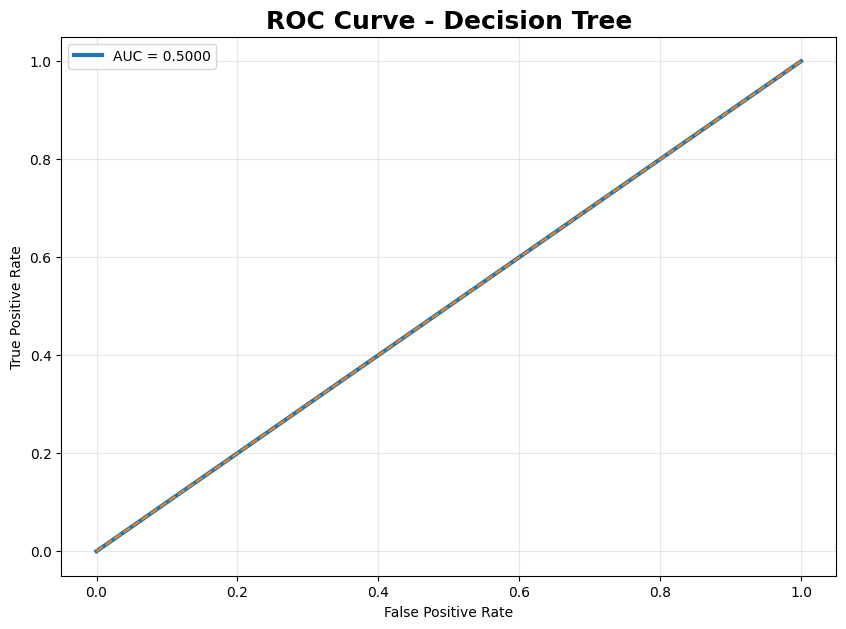

AUC Score: 0.5


In [32]:
y_true = [
    row["delay_label"]
    for row in dt_predictions.select("delay_label").collect()
]

y_score = [
    float(row["probability"][1])
    for row in dt_predictions.select("probability").collect()
]

fpr, tpr, _ = roc_curve(
    y_true,
    y_score
)

roc_auc = auc(
    fpr,
    tpr
)

plt.figure(figsize=(10,7))

plt.plot(
    fpr,
    tpr,
    linewidth=3,
    label=f"AUC = {roc_auc:.4f}"
)

plt.plot([0,1],[0,1],"--")

plt.title(
    "ROC Curve - Decision Tree",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.legend()

plt.grid(alpha=0.3)

plt.show()

print("AUC Score:", round(roc_auc,4))

#ROC CURVE OF SVM

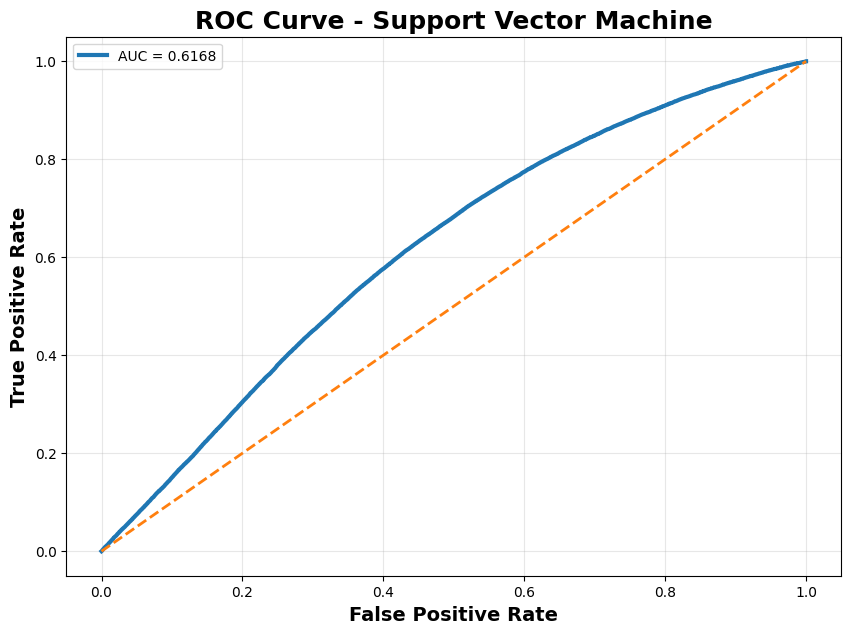

AUC Score: 0.6168


In [33]:
# Actual labels

y_true = [
    row["delay_label"]
    for row in svm_predictions.select("delay_label").collect()
]

# Extract positive-class score

y_score = [
    float(row["rawPrediction"][1])
    for row in svm_predictions.select("rawPrediction").collect()
]

# ROC

fpr, tpr, _ = roc_curve(
    y_true,
    y_score
)

roc_auc = auc(
    fpr,
    tpr
)

# Plot

plt.figure(figsize=(10,7))

plt.plot(
    fpr,
    tpr,
    linewidth=3,
    label=f"AUC = {roc_auc:.4f}"
)

plt.plot(
    [0,1],
    [0,1],
    linestyle="--",
    linewidth=2
)

plt.title(
    "ROC Curve - Support Vector Machine",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel(
    "False Positive Rate",
    fontsize=14,
    fontweight="bold"
)

plt.ylabel(
    "True Positive Rate",
    fontsize=14,
    fontweight="bold"
)

plt.legend()

plt.grid(alpha=0.3)

plt.show()

print("AUC Score:", round(roc_auc,4))

#ROC CURVE OF KNN CLASSIFIER

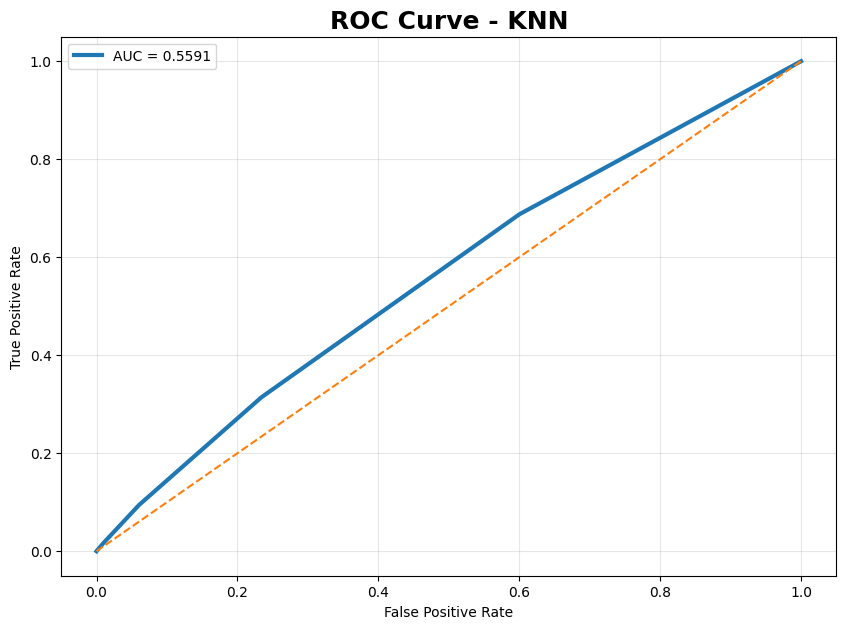

In [34]:
y_prob = knn.predict_proba(X_test)[:,1]

fpr, tpr, _ = roc_curve(
    y_test,
    y_prob
)

roc_auc = auc(
    fpr,
    tpr
)

plt.figure(figsize=(10,7))

plt.plot(
    fpr,
    tpr,
    linewidth=3,
    label=f"AUC = {roc_auc:.4f}"
)

plt.plot([0,1],[0,1],"--")

plt.title(
    "ROC Curve - KNN",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.legend()

plt.grid(alpha=0.3)

plt.show()


#Precision-recall curve of Logistic Regression

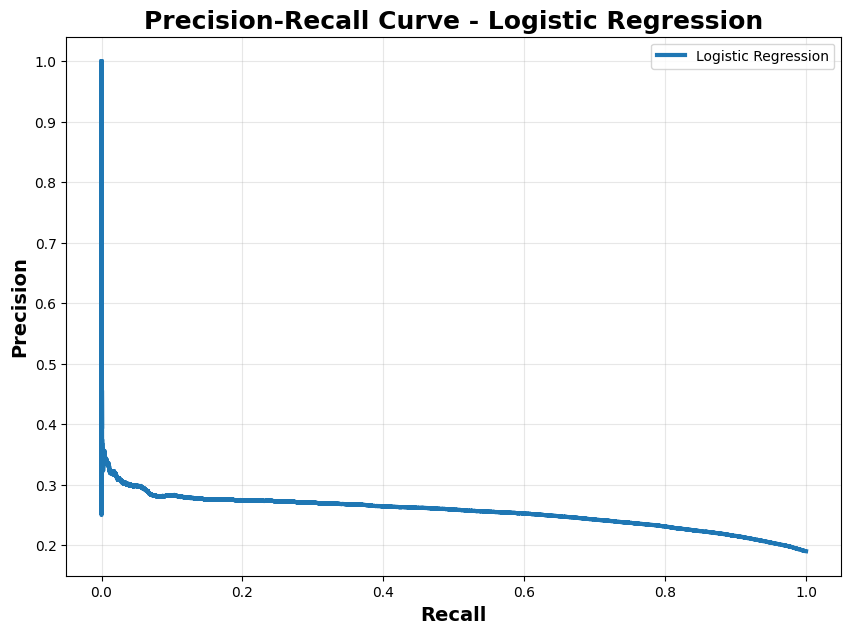

In [35]:
y_true = [
    row["delay_label"]
    for row in lr_predictions.select("delay_label").collect()
]

y_score = [
    float(row["probability"][1])
    for row in lr_predictions.select("probability").collect()
]

precision, recall, _ = precision_recall_curve(
    y_true,
    y_score
)

plt.figure(figsize=(10,7))

plt.plot(
    recall,
    precision,
    linewidth=3,
    label="Logistic Regression"
)

plt.xlabel(
    "Recall",
    fontsize=14,
    fontweight="bold"
)

plt.ylabel(
    "Precision",
    fontsize=14,
    fontweight="bold"
)

plt.title(
    "Precision-Recall Curve - Logistic Regression",
    fontsize=18,
    fontweight="bold"
)

plt.grid(alpha=0.3)

plt.legend()

plt.show()

#Precision-Recall of Decision Tree

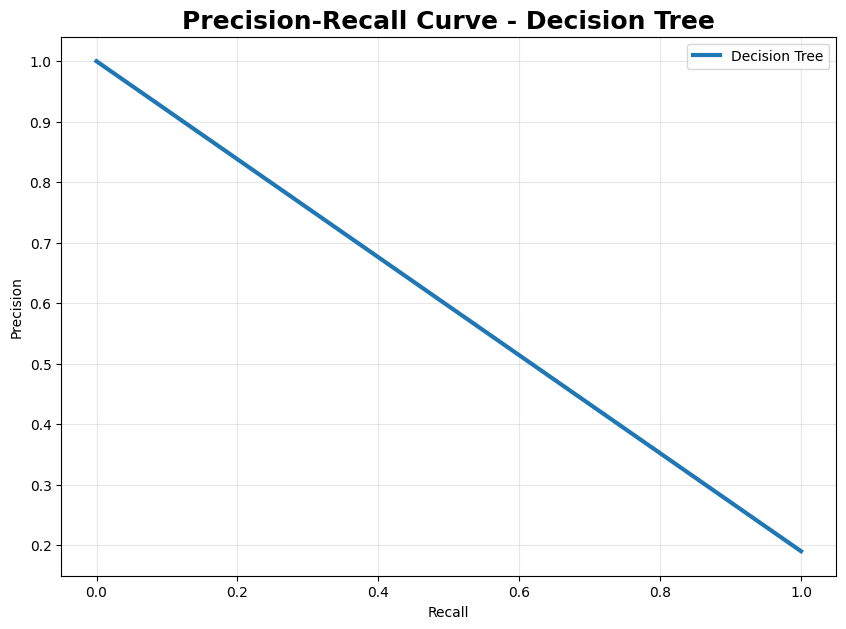

In [36]:
y_true = [
    row["delay_label"]
    for row in dt_predictions.select("delay_label").collect()
]

y_score = [
    float(row["probability"][1])
    for row in dt_predictions.select("probability").collect()
]

precision, recall, _ = precision_recall_curve(
    y_true,
    y_score
)

plt.figure(figsize=(10,7))

plt.plot(
    recall,
    precision,
    linewidth=3,
    label="Decision Tree"
)

plt.xlabel("Recall")
plt.ylabel("Precision")

plt.title(
    "Precision-Recall Curve - Decision Tree",
    fontsize=18,
    fontweight="bold"
)

plt.grid(alpha=0.3)

plt.legend()

plt.show()


#Precision-Recall of SVM

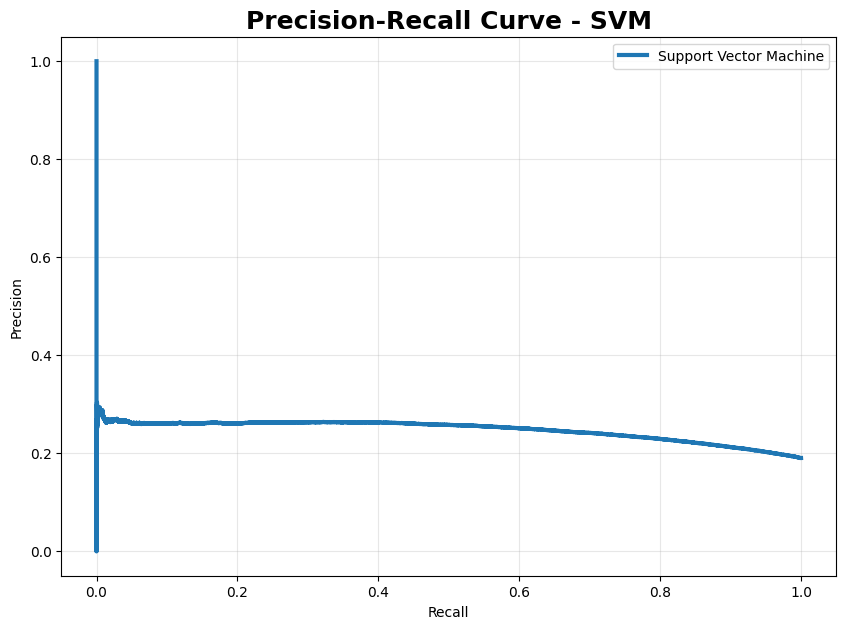

In [37]:
from sklearn.metrics import precision_recall_curve

y_true = [
    row["delay_label"]
    for row in svm_predictions.select("delay_label").collect()
]

y_score = [
    float(row["rawPrediction"][1])
    for row in svm_predictions.select("rawPrediction").collect()
]

precision, recall, _ = precision_recall_curve(
    y_true,
    y_score
)

plt.figure(figsize=(10,7))

plt.plot(
    recall,
    precision,
    linewidth=3,
    label="Support Vector Machine"
)

plt.xlabel("Recall")
plt.ylabel("Precision")

plt.title(
    "Precision-Recall Curve - SVM",
    fontsize=18,
    fontweight="bold"
)

plt.grid(alpha=0.3)

plt.legend()

plt.show()

#Precision-Recall of KNN

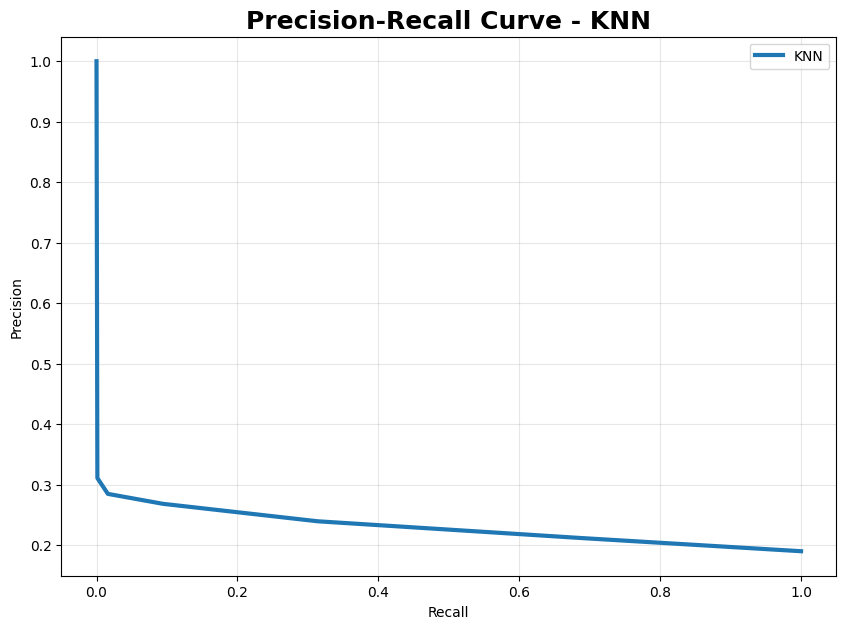

In [38]:
from sklearn.metrics import precision_recall_curve

y_prob = knn.predict_proba(X_test)[:,1]

precision, recall, _ = precision_recall_curve(
    y_test,
    y_prob
)

plt.figure(figsize=(10,7))

plt.plot(
    recall,
    precision,
    linewidth=3,
    label="KNN"
)

plt.xlabel("Recall")
plt.ylabel("Precision")

plt.title(
    "Precision-Recall Curve - KNN",
    fontsize=18,
    fontweight="bold"
)

plt.grid(alpha=0.3)

plt.legend()

plt.show()

#Perturbed Analysis of the Logistic Regression

In [39]:
from pyspark.sql.functions import rand
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

evaluator = MulticlassClassificationEvaluator(
    labelCol="delay_label",
    predictionCol="prediction",
    metricName="accuracy"
)

# Original Accuracy

original_lr_acc = evaluator.evaluate(
    lr_predictions
)

# Perturbed Prediction

perturbed_lr = lr_model.transform(
    test_df.withColumn(
        "distance",
        test_df["distance"] * (1 + rand(seed=42) * 0.05)
    )
)

perturbed_lr_acc = evaluator.evaluate(
    perturbed_lr
)

print("Original Accuracy :", round(original_lr_acc,4))
print("Perturbed Accuracy:", round(perturbed_lr_acc,4))
print("Difference:", round(
    original_lr_acc - perturbed_lr_acc,
    4
))

Original Accuracy : 0.8098
Perturbed Accuracy: 0.8098
Difference: 0.0


#Perturbed Analysis of Decision Tree

In [40]:
original_dt_acc = evaluator.evaluate(
    dt_predictions
)

perturbed_dt = test_df.withColumn(
    "distance",
    test_df["distance"] * (1 + rand(seed=42)*0.05)
)


perturbed_dt_pred = dt_model.transform(
    perturbed_dt
)

perturbed_dt_acc = evaluator.evaluate(
    perturbed_dt_pred
)

print("Original Accuracy :", round(original_dt_acc,4))
print("Perturbed Accuracy:", round(perturbed_dt_acc,4))
print("Difference:", round(
    original_dt_acc - perturbed_dt_acc,
    4
))

Original Accuracy : 0.8098
Perturbed Accuracy: 0.8098
Difference: 0.0


#Perturbed Analysis of SVM

In [41]:
# Evaluator

evaluator = MulticlassClassificationEvaluator(
    labelCol="delay_label",
    predictionCol="prediction",
    metricName="accuracy"
)

# Original Accuracy

original_svm_acc = evaluator.evaluate(
    svm_predictions
)

# Perturb Features

def perturb_features(v):
    arr = np.array(v.toArray())
    arr = arr * (1 + np.random.normal(0, 0.05, len(arr)))
    return Vectors.dense(arr)

perturb_udf = udf(
    perturb_features,
    VectorUDT()
)

perturbed_test = test_df.withColumn(
    "features",
    perturb_udf("features")
)

# Predict

perturbed_svm_pred = svm_model.transform(
    perturbed_test
)

# Accuracy

perturbed_svm_acc = evaluator.evaluate(
    perturbed_svm_pred
)

print("Original Accuracy :", round(original_svm_acc,4))
print("Perturbed Accuracy:", round(perturbed_svm_acc,4))
print("Difference:", round(
    original_svm_acc - perturbed_svm_acc,
    4
))

Original Accuracy : 0.8098
Perturbed Accuracy: 0.8098
Difference: 0.0


#Perturbed Analysis of KNN

In [42]:
# Original Accuracy

original_knn_acc = accuracy_score(
    y_test,
    y_pred

)

# Addition of 5% Gaussian Noise

X_test_perturbed = (
    np.array(X_test)
    *
    (1 + np.random.normal(
        0,
        0.05,
        np.array(X_test).shape
    ))
)

# Prediction

y_pred_perturbed = knn.predict(
    X_test_perturbed
)

# Accuracy

perturbed_knn_acc = accuracy_score(
    y_test,
    y_pred_perturbed
)

print("Original Accuracy :", round(original_knn_acc,4))
print("Perturbed Accuracy:", round(perturbed_knn_acc,4))
print("Difference:", round(
    original_knn_acc - perturbed_knn_acc,
    4
))

Original Accuracy : 0.8098
Perturbed Accuracy: 0.7784
Difference: 0.0314


#Installtion of SHAP

In [43]:
!pip install shap

#SHAP Output for KNN

In [44]:
print("Number of Features:", len(X_train[0]))

Number of Features: 6


In [45]:
print("X_train shape:", np.array(X_train).shape)
print("X_test shape:", np.array(X_test).shape)

print("Length of first row:")
print(len(X_train[0]))

X_train shape: (960937, 6)
X_test shape: (240267, 6)
Length of first row:
6


  0%|          | 0/20 [00:00<?, ?it/s]

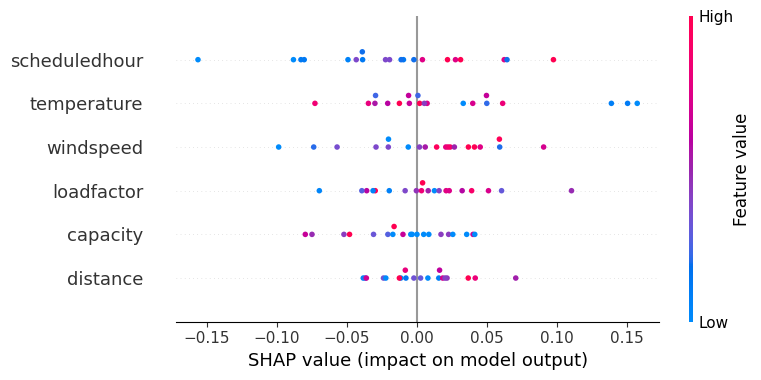

In [46]:
feature_names = [
    "distance",
    "temperature",
    "windspeed",
    "capacity",
    "loadfactor",
    "scheduledhour"
]

# Converting to NumPy

X_train_np = np.array(X_train)
X_test_np = np.array(X_test)

# Smaller samples

background = X_train_np[:30]
sample_data = X_test_np[:20]

# SHAP Explainer

explainer = shap.KernelExplainer(
    knn.predict_proba,
    background
)

# Calculation of SHAP values

shap_values = explainer.shap_values(sample_data)

# Extract Class 1 (Delay)

if len(shap_values.shape) == 3:
    shap_values = shap_values[:, :, 1]

# Smaller figure

plt.figure(figsize=(6,4))

shap.summary_plot(
    shap_values,
    sample_data,
    feature_names=feature_names,
    max_display=6,
    show=False
)

plt.tight_layout()
plt.show()

#SHAP Output of Logistic Regression

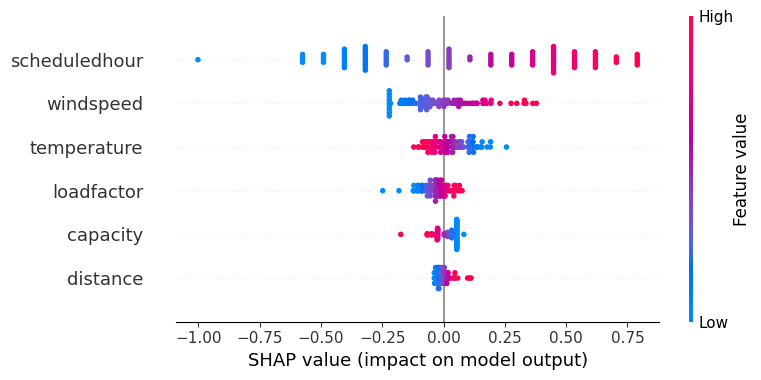

In [47]:
from sklearn.linear_model import LogisticRegression as SklearnLogisticRegression

feature_names = [
    "distance",
    "temperature",
    "windspeed",
    "capacity",
    "loadfactor",
    "scheduledhour"
]

# Training sklearn model

lr_sk = SklearnLogisticRegression(
    max_iter=1000,
    random_state=42
)

lr_sk.fit(X_train, y_train)

# SHAP Explainer

explainer = shap.Explainer(
    lr_sk,
    np.array(X_train)
)

shap_values = explainer(
    np.array(X_test[:100])
)

# Smaller figure

plt.figure(figsize=(7,4))

shap.summary_plot(
    shap_values.values,
    np.array(X_test[:100]),
    feature_names=feature_names,
    max_display=6
)

#SHAP Output of Decision Tree

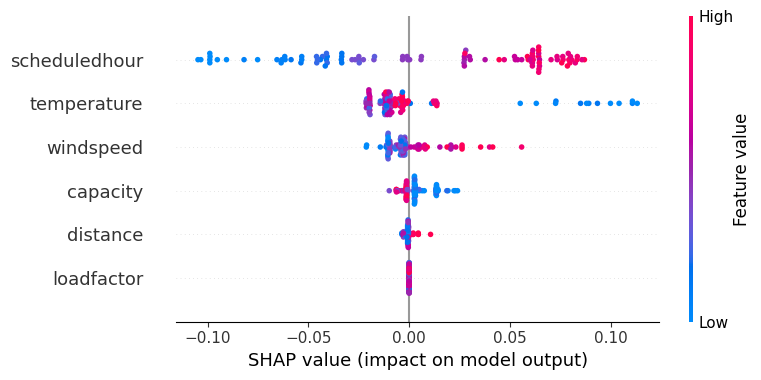

In [48]:
from sklearn.tree import DecisionTreeClassifier
feature_names = [
    "distance",
    "temperature",
    "windspeed",
    "capacity",
    "loadfactor",
    "scheduledhour"
]

# Training sklearn Decision Tree

dt_sk = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)

dt_sk.fit(X_train, y_train)

# SHAP Tree Explainer

explainer = shap.TreeExplainer(
    dt_sk
)

shap_values = explainer.shap_values(
    np.array(X_test[:100])
)

# For binary classification
if isinstance(shap_values, list):
    shap_plot_values = shap_values[1]
elif len(np.array(shap_values).shape) == 3:
    shap_plot_values = shap_values[:, :, 1]
else:
    shap_plot_values = shap_values

# Creation of figure

plt.figure(figsize=(8,5))

shap.summary_plot(
    shap_plot_values,
    np.array(X_test[:100]),
    feature_names=[
        "distance",
        "temperature",
        "windspeed",
        "capacity",
        "loadfactor",
        "scheduledhour"
    ],
    max_display=6,
    plot_type="dot",
    show=False
)

plt.tight_layout()
plt.show()